In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, sys
from sklearn.metrics import confusion_matrix
import seaborn as sns
from collections import Counter


from sklearn.model_selection import train_test_split
sys.path.append('../../Share/')
import Model

def random_downsample_Num(X, y=None, n_keep=None, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    if n_keep is None or n_keep > n_samples:
        raise ValueError(f"n_keep must be between 1 and {n_samples}, got {n_keep}")

    idx_keep = np.random.choice(n_samples, size=n_keep, replace=False)
    X_down = X[idx_keep]

    if y is not None:
        y_down = y[idx_keep]
        return X_down, y_down
    else:
        return X_down


def filtering_zero(X, y, erase_label):
    # 1. erase_label 제거
    keep_indices = y != erase_label
    X = X[keep_indices]
    y = y[keep_indices]

    # 2. erase_label보다 큰 값은 1씩 감소
    y = np.where(y > erase_label, y - 1, y)

    return X, y


def heatmap_confusion_matrix(X_test, y_test, model):
    # Predict class labels on the test set
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)  # convert softmax probs to predicted class
    y_true = y_test
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(np.max(y_test)+1), yticklabels=range(np.max(y_test)+1))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    return cm

def vis_graph(history):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.legend()
    plt.show()

def train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False):
    X_train, y_train = filtering_zero(X_train, y_train, erase_label=0)
    X_test, y_test = filtering_zero(X_test, y_test, erase_label=0)

    model = Model.Original_model(X_train.shape[1:], num_class=np.max(y_train)+1)

    history, model = Model.Train_model(
        model, X_train, y_train, X_test, y_test,
        set_epoch=100, set_batch_size=256, Model_name='V0',
        set_verbose=False, save_model_set=False
    )
    if draw_learning_curve:
        vis_graph(history)

    if heatmap_bool:
        CM = heatmap_confusion_matrix(X_test, y_test, model)
        return CM

    return None

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

def get_X_y(X_lst, y_lst, session, balance=True):
    X, y = [], []
    for t in session:
        X_tmp, y_tmp = X_lst[t].reshape(-1,16,14,1), y_lst[t]
        X.append(X_tmp)
        y.append(y_tmp)

    X, y = np.concatenate(X, axis=0), np.concatenate(y, axis=0)
    if balance:
        X,y = balance_data(X, y)
    return X, y

In [6]:
# subject 1 - dont use

path = 'C:/Users/hml76/Desktop/Jupyter/Federated Prototype Learning/Dataset/Ours_cleaned/'
fname = os.listdir(path)

subjects = {
    "subject1": {"X": [], "Y": []},
    "subject2": {"X": [], "Y": []},
    "subject3": {"X": [], "Y": []},
}

for f in fname:
    for i in range(10):
        X = np.array(pd.read_csv(path + f'{f}/rep{i}_X.csv'))
        y = np.array(pd.read_csv(path + f'{f}/rep{i}_Y.csv'))

        # shuffle
        #indices = np.random.permutation(len(X))
        #X, y = X[indices], y[indices]

        # convert one-hot to integer labels
        y_int = np.argmax(y, axis=1)
        num_classes = np.max(y_int) + 1

        # example rule to assign data to subject dict
        if "subject1" in f:
            subjects["subject1"]["X"].append(X)
            subjects["subject1"]["Y"].append(y_int)
        elif "subject2" in f:
            subjects["subject2"]["X"].append(X)
            subjects["subject2"]["Y"].append(y_int)
        elif "subject3" in f:
            subjects["subject3"]["X"].append(X)
            subjects["subject3"]["Y"].append(y_int)

7 8
(52092, 16, 14, 1) (52092,) (13998, 16, 14, 1) (13998,)
Start Training (total epochs: 100)...
Maximum training accuracy : 73.31%
Maximum validation accuracy : 47.48%


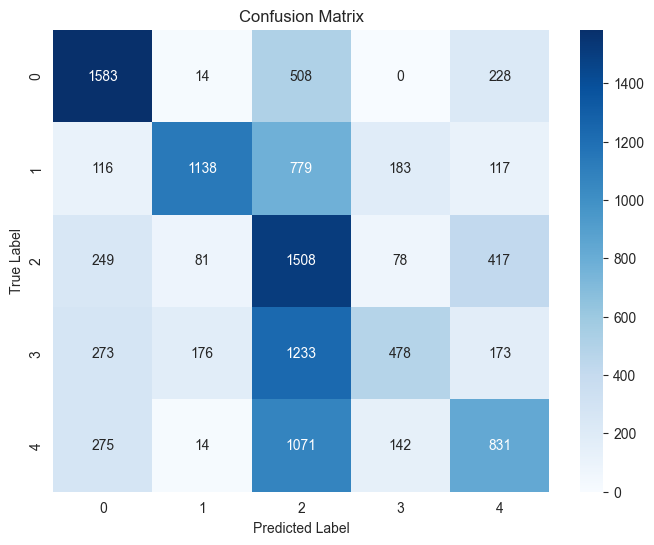

9 6
(52710, 16, 14, 1) (52710,) (13380, 16, 14, 1) (13380,)
Start Training (total epochs: 100)...
Maximum training accuracy : 72.78%
Maximum validation accuracy : 54.66%


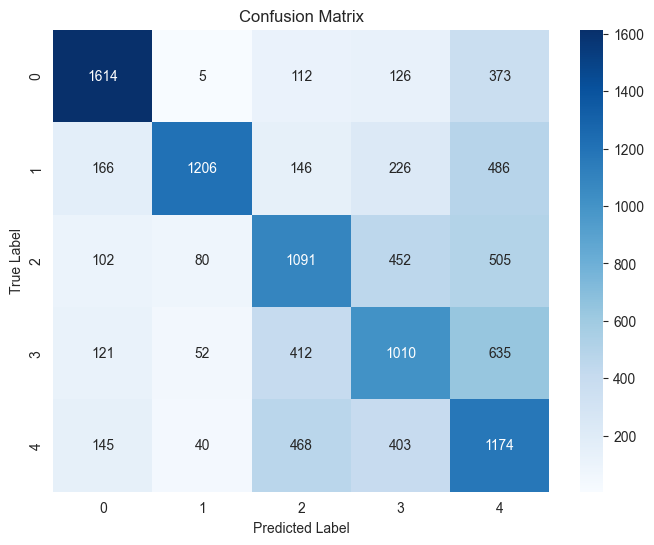

0 8
(53526, 16, 14, 1) (53526,) (12036, 16, 14, 1) (12036,)
Start Training (total epochs: 100)...
Maximum training accuracy : 73.49%
Maximum validation accuracy : 49.79%


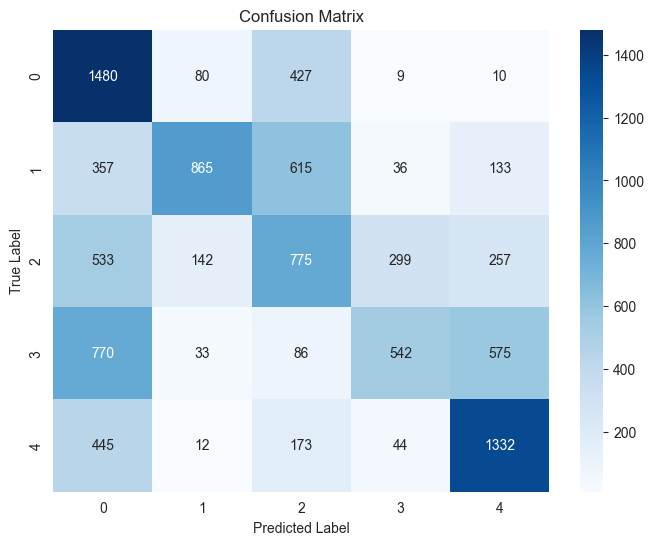

8 4
(51444, 16, 14, 1) (51444,) (13332, 16, 14, 1) (13332,)
Start Training (total epochs: 100)...
Maximum training accuracy : 71.66%
Maximum validation accuracy : 49.86%


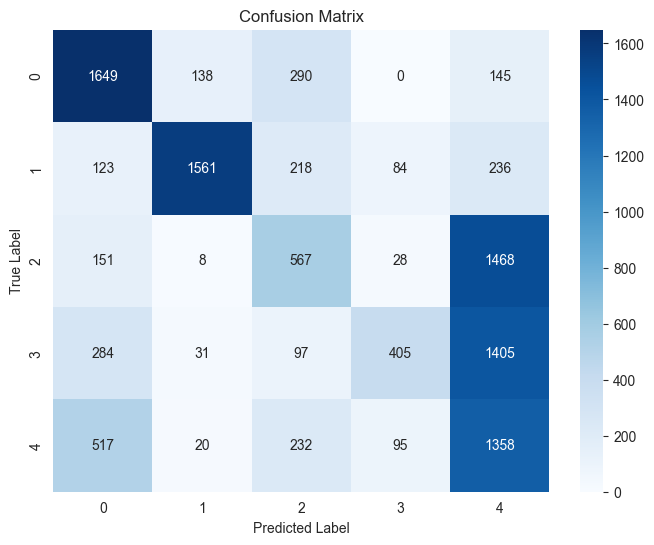

2 8
(51630, 16, 14, 1) (51630,) (13338, 16, 14, 1) (13338,)
Start Training (total epochs: 100)...


In [ ]:
X_lst2, y_lst2 = subjects["subject2"]["X"], subjects["subject2"]["Y"]
import random
CM_lst_S2 = []

for repeat in range(5):
    numbers = list(range(10))
    a, b = random.sample(numbers, 2)
    numbers.remove(a)
    numbers.remove(b)
    print(a,b)

    X_train, y_train = get_X_y(X_lst2, y_lst2, session=numbers, balance=True)
    X_test, y_test = get_X_y(X_lst2, y_lst2, session=[a,b], balance=True) #2개씩 해야함 - 10tirals *2 = 20 = same with the sENG setting

    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    CM_s2 = train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False)
    CM_lst_S2.append(CM_s2)

In [ ]:
X_lst3, y_lst3 = subjects["subject3"]["X"], subjects["subject3"]["Y"]
import random
CM_lst_S3 = []

for repeat in range(5):
    numbers = list(range(10))
    a, b = random.sample(numbers, 2)
    numbers.remove(a)
    numbers.remove(b)
    print(a,b)

    X_train, y_train = get_X_y(X_lst3, y_lst3, session=numbers, balance=True)
    X_test, y_test = get_X_y(X_lst3, y_lst3, session=[a,b], balance=True) #2개씩 해야함 - 10tirals *2 = 20 = same with the sENG setting

    print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
    CM_s3 = train_model(X_train, y_train, X_test, y_test, heatmap_bool=True, draw_learning_curve=False)
    CM_lst_S3.append(CM_s3)

In [ ]:
np.mean(CM_lst_S2, axis=0)

In [ ]:
np.mean(CM_lst_S2, axis=1)

In [ ]:
np.mean(CM_lst_S2, axis=0)

In [16]:
`pd.DataFrame(CM_s2).to_csv('./Amputee-iENG-S2.csv', index=False)
pd.DataFrame(CM_s3).to_csv('./Amputee-iENG-S3.csv', index=False)